# Support Vector Machines (SVM)

#### Linear Separability and Support Vectors
##### Dataset: from sklearn.datasets import make_blobs
##### Task: Generate a synthetic, perfectly linearly separable 2D dataset using make_blobs from sklearn.datasets.
##### Action: Train a Linear SVM (kernel='linear'). Extract the coordinates of the Support Vectors from the trained model and plot the data points, highlighting the support vectors and drawing the separating hyperplane (decision boundary)

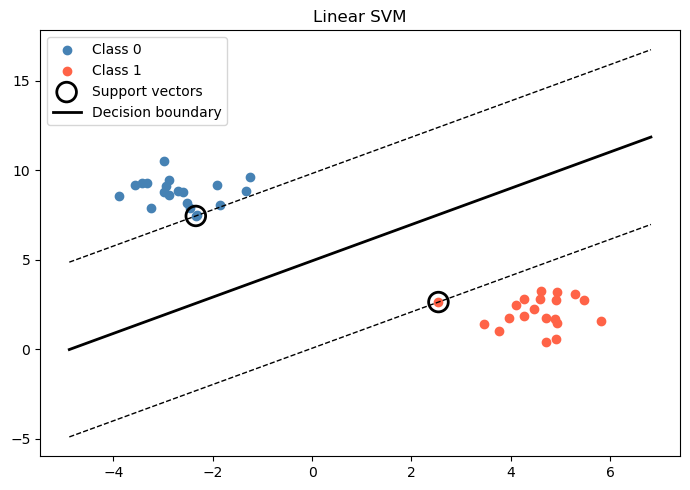

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
 
X, y = make_blobs(n_samples=40, centers=2, cluster_std=0.8, random_state=42)
 
clf = SVC(kernel='linear', C=1.0)
clf.fit(X, y)
 
w = clf.coef_[0]
b = clf.intercept_[0]
xx = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300)
 
fig, ax = plt.subplots(figsize=(7, 5))
 
ax.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', label='Class 0')
ax.scatter(X[y==1, 0], X[y==1, 1], c='tomato', label='Class 1')
 
sv = clf.support_vectors_
ax.scatter(sv[:,0], sv[:,1], s=200, facecolors='none', edgecolors='black', linewidths=2, label='Support vectors', zorder=5)
 
ax.plot(xx, (-w[0]*xx - b) / w[1], 'k-', lw=2, label='Decision boundary')
ax.plot(xx, (-w[0]*xx - b + 1) / w[1], 'k--', lw=1)
ax.plot(xx, (-w[0]*xx - b - 1) / w[1], 'k--', lw=1)
 
ax.legend()
ax.set_title('Linear SVM')
plt.tight_layout()

#### The Kernel Trick
##### Dataset: from sklearn.datasets import make_moons
##### Task: Generate a non-linearly separable dataset (e.g., using make_moons or make_circles).
##### Action: Train three different SVM models on this data: one with a Linear kernel, one with a Polynomial kernel, and one with an RBF (Radial Basis Function) kernel. Plot the decision boundaries for all three to visually demonstrate how the Kernel Trick allows SVM to solve non-linear problems.

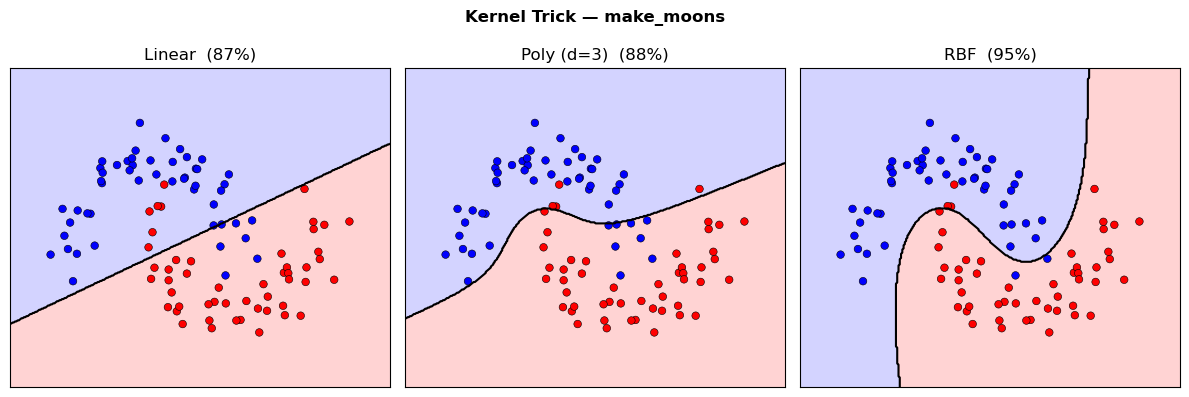

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
 
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)
 
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-.5, X[:,0].max()+.5, 300),
                     np.linspace(X[:,1].min()-.5, X[:,1].max()+.5, 300))
 
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
 
for ax, kernel, title in zip(axes,
                              ['linear', 'poly', 'rbf'],
                              ['Linear', 'Poly (d=3)', 'RBF']):
    clf = SVC(kernel=kernel, degree=3, gamma='scale').fit(X, y)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap='bwr')
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=1.5)
    ax.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k', lw=0.4, s=30)
    ax.set_title(f'{title}  ({clf.score(X,y):.0%})')
    ax.set_xticks([]); ax.set_yticks([])
 
plt.suptitle('Kernel Trick — make_moons', fontweight='bold')
plt.tight_layout()